This notebook is designed to analyze the characteristics of a single Type II sample across a range of temperatures.

The aim of this notebook is to produce a scatter plot of critical fields at certain temperatures

In [22]:
# Import necessary librarys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import pandas as pd
import glob
from scipy.signal import medfilt
from scipy.signal import savgol_filter

In [37]:
# Import mutliple .txt files

# Combine all files for a given sample

# Available samples: (SNPB, PTFE, IN2BI, IN4BI)
# Replace blank in "sc_data/__/*.txt" with sample name
metal = "SNPB"


files = glob.glob(f"../meissner/{metal}/sc_data/*.txt")


# Create dictionary of superconductor files
sc_data = {}

# read files into dictionary
for file in files:
    sc_data[file] = pd.read_csv(file, sep=r"\s+")

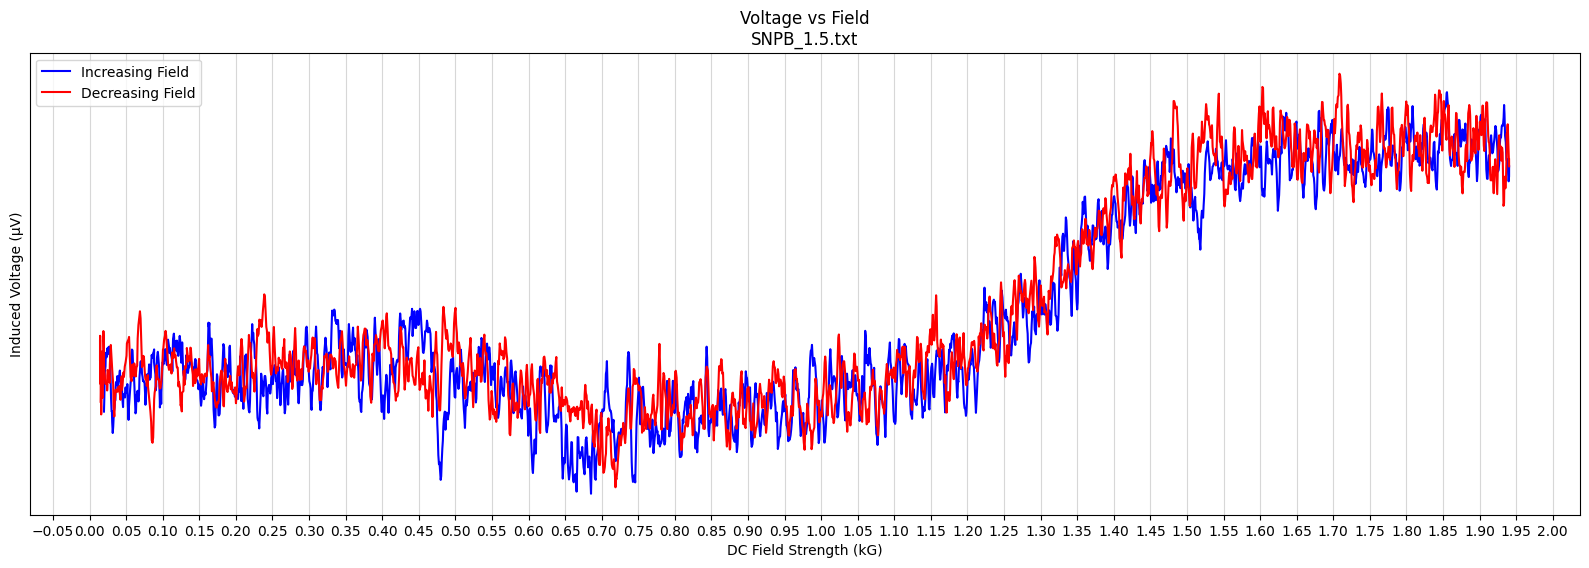

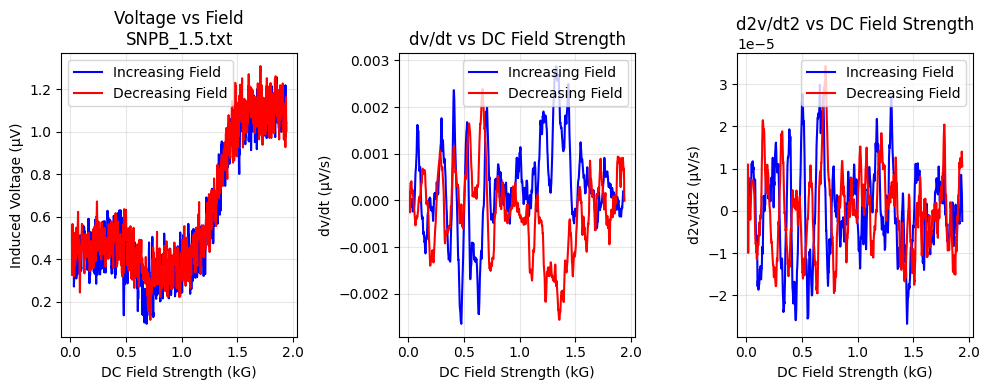

In [38]:
# Constants
tau = 0.3
cutoff = 5 * tau

for file_path, df_unclean in sc_data.items():
    
    # 1. Separate and Clean Data
    mask = df_unclean["Time(s)"] > cutoff
    df = df_unclean[mask].copy()
    
    # 2. Find split point (Peak of Channel 1)
    max_field_idx = df["Channel_1(V)"].abs().idxmax()
    
    # 3. Split data into segments
    up_sweep = df.loc[:max_field_idx].copy()
    down_sweep = df.loc[max_field_idx:].copy()
    
    # 4. Process UP Sweep
    t_up = up_sweep["Time(s)"]
    kGauss_up = up_sweep["Channel_1(V)"].abs()
    voltage_up = medfilt(up_sweep["Channel_2(V)"], kernel_size=13)
    voltage_up = up_sweep["Channel_2(V)"]
    
    # 5. Process DOWN Sweep
    t_down = down_sweep["Time(s)"]
    kGauss_down = down_sweep["Channel_1(V)"].abs()
    voltage_down = medfilt(down_sweep["Channel_2(V)"], kernel_size=13)
    voltage_down = down_sweep["Channel_2(V)"]

    # 6. Calculate dv/dt using numpy gradient
    # This calculates the derivative of voltage with respect to time

    window = 201   # must be odd
    poly = 3      # polynomial order

    v_sav_up = savgol_filter(voltage_up, window_length=window, polyorder=poly)
    d1v_up = savgol_filter(voltage_up, window_length=window, polyorder=poly, mode='mirror', deriv=1)
    d2v_up = savgol_filter(voltage_up, window_length=window, polyorder=poly,mode='mirror', deriv=2)

    v_sav_down = savgol_filter(voltage_down, window_length=window, polyorder=poly)
    d1v_down = savgol_filter(voltage_down, window_length=window, polyorder=poly, mode='mirror', deriv=1)
    d2v_down = savgol_filter(voltage_down, window_length=window, polyorder=poly, mode='mirror', deriv=2)

    # --- Plotting Section ---

     # Plot 1: Induced Voltage vs kGauss
    # Set figure size here
    fig, ax = plt.subplots(figsize=(20, 6))  # width=10, height=6 inches

    # Plot your curves
    ax.plot(kGauss_up, voltage_up, label='Increasing Field', color='blue')
    ax.plot(kGauss_down, voltage_down, label='Decreasing Field', color='red')

    # Set x-axis ticks every 0.5 kG
    ax.xaxis.set_major_locator(MultipleLocator(0.05))


    # Set y-axis ticks (example: every 10 µV)
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.set_minor_locator(MultipleLocator(2))

    # Add grid
    ax.grid(which='major', alpha=0.5)
    ax.grid(which='minor', alpha=0.2)

    # Labels, title, legend
    ax.set_xlabel("DC Field Strength (kG)")
    ax.set_ylabel("Induced Voltage (µV)")
    ax.set_title(f"Voltage vs Field\n{file_path.split('/')[-1]}")
    ax.legend()

    plt.show()

    # Plot 1: Induced Voltage vs kGauss
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 3, 1) # Left side plot
    plt.plot(kGauss_up, voltage_up, label='Increasing Field', color='blue')
    plt.plot(kGauss_down, voltage_down, label='Decreasing Field', color='red')
    plt.xlabel("DC Field Strength (kG)")
    plt.ylabel("Induced Voltage (\u03bcV)")
    plt.title(f"Voltage vs Field\n{file_path.split('/')[-1]}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 2: dv/dt vs kGauss
    plt.subplot(1, 3, 2) # Right side plot
    plt.plot(kGauss_up, d1v_up, label='Increasing Field', color='blue')
    plt.plot(kGauss_down, d1v_down, label='Decreasing Field', color='red')
    plt.xlabel("DC Field Strength (kG)")
    plt.ylabel("dv/dt (\u03bcV/s)")
    plt.title("dv/dt vs DC Field Strength")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 3: d2v/dt2 vs kGauss
    plt.subplot(1, 3, 3) # Right side plot
    plt.plot(kGauss_up, d2v_up, label='Increasing Field', color='blue')
    plt.plot(kGauss_down, d2v_down, label='Decreasing Field', color='red')
    plt.xlabel("DC Field Strength (kG)")
    plt.ylabel("d2v/dt2 (\u03bcV/s)")
    plt.title("d2v/dt2 vs DC Field Strength")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout() # Prevents labels from overlapping
    plt.show()